# Case study: pricing and hedging an FX option sold to an Italian exporter

**Business question.** An Italian machinery exporter will receive USD 11-12 million in six months and asks its bank for protection
against a weaker dollar: a six-month **EUR call / USD put** on EUR 10 million, struck at the forward. The bank's FX options desk sells the
option and delta-hedges it in the spot market. The head of the desk needs to know:

1. What volatility does the market history of EUR/USD justify for the next six months?
2. How large and how fat-tailed is the P&L of the hedged position, and how does it depend on the hedging frequency and on costs?
3. How much does the answer depend on the model assumed for EUR/USD (model risk)?
4. Which volatility should the desk quote so that the trade is profitable with high probability and its tail risk is remunerated?

**Method.** EUR/USD dynamics are estimated on the **official ECB euro reference rates** with a GJR-GARCH model with Student-t innovations
(C++ maximum likelihood). The desk's P&L is simulated in C++ for 200,000 paths under three dynamics: geometric Brownian motion,
Heston stochastic volatility and **filtered historical simulation** (GARCH volatility with resampled historical shocks). Interest rates
come from the ECB AAA yield curve (EUR) and the 3-month US Treasury bill rate from FRED (USD). Currency options are priced with
Garman-Kohlhagen.

**Conventions.** EUR/USD is quoted in USD per EUR (the ECB convention); the domestic currency is USD and the foreign one EUR, so the option
premium is in USD per EUR of notional and is converted to EUR at the spot rate. Rates are continuously compounded; one year has 252 trading days.
The analysis is illustrative: it ignores the bank's credit valuation adjustment, funding costs and the smile of the interbank option market.

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "quant_engine").is_dir())
try:
    import quant_engine
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "quant_engine"))
    import quant_engine
from quant_engine import curves, data, garch, hedging, synthetic

core = quant_engine.require_cpp()

DATA_MODE = os.environ.get("QUANT_ENGINE_DATA_MODE", "official")  # "official" or "synthetic"
VALUATION_DATE = "2025-12-31"
NOTIONAL_EUR = 10_000_000          # client notional
TENOR_DAYS = 126                    # six months of trading days
T = TENOR_DAYS / 252
COST_RATE = 0.5e-4                  # 0.5 bp of the traded amount: interbank half spread plus fees on EUR/USD spot
ASSUMED_RATES = {"EUR": 0.020, "USD": 0.040}  # used only if the official rates cannot be downloaded
N_PATHS = 200_000
SEED = 20251231
OUTPUT_DIR = ROOT / "outputs" / "fx_option_desk"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
from quant_engine.figstyle import MUTED, NEGATIVE, SERIES, notebook_style, ordinal_colors
notebook_style()   # validated palette, recessive grid, constrained layout (see figstyle.py)
print(f"quant_engine {quant_engine.__version__} | data mode: {DATA_MODE} | threads: {os.cpu_count()}")

quant_engine 0.1.0 | data mode: official | threads: 4


## 1. Market data at the valuation date

In [2]:
def rate_or_assumption(label, loader):
    """Download an official rate; if the source is unreachable, fall back to the documented assumption."""
    try:
        value, source = loader()
        print(f"{label}: {100 * value:.3f}% ({source})")
        return value
    except Exception as exc:  # network errors, missing series
        value = ASSUMED_RATES[label]
        print(f"WARNING: {label} rate not available ({type(exc).__name__}); using the assumption {100 * value:.2f}%")
        return value

if DATA_MODE == "official":
    fx = data.load_ecb_fx_rates(("USD",), end=VALUATION_DATE)["USD"].dropna()

    def eur_rate():
        sv = data.load_ecb_svensson_parameters("2025-12-01", VALUATION_DATE)
        return float(curves.SvenssonCurve.from_series(sv.iloc[-1]).zero_rate(T)), "ECB AAA curve, 6-month zero rate"

    def usd_rate():
        bill = data.load_fred("DTB3", end=VALUATION_DATE)
        return float(np.log1p(bill.iloc[-1] / 100.0)), f"FRED DTB3 on {bill.index[-1]:%Y-%m-%d}, converted to continuous compounding"

    r_eur, r_usd = rate_or_assumption("EUR", eur_rate), rate_or_assumption("USD", usd_rate)
else:
    fx = synthetic.fx_rates(end=VALUATION_DATE)["USD"]
    r_eur, r_usd = ASSUMED_RATES["EUR"], ASSUMED_RATES["USD"]
    print("Synthetic mode: illustrative rates", ASSUMED_RATES)
print("FX source:", fx.attrs.get("source", "ECB euro reference rates"))

spot = float(fx.iloc[-1])
forward = spot * np.exp((r_usd - r_eur) * T)
strike = forward
returns = 100 * np.log(fx).diff().dropna()      # daily log-returns of EUR/USD, percent
print(f"Spot EUR/USD {spot:.4f} on {fx.index[-1]:%Y-%m-%d}; 6-month forward {forward:.4f}; strike (ATM forward) {strike:.4f}")
print(f"History: {len(returns):,} daily returns since {returns.index[0]:%Y-%m-%d}; "
      f"realised volatility: full sample {returns.std() * np.sqrt(252):.2f}%, last 3 months {returns.iloc[-63:].std() * np.sqrt(252):.2f}%")

EUR: 1.993% (ECB AAA curve, 6-month zero rate)
USD: 3.508% (FRED DTB3 on 2025-12-31, converted to continuous compounding)
FX source: European Central Bank, euro foreign exchange reference rates (https://www.ecb.europa.eu/stats/eurofxref/eurofxref-hist.zip)
Spot EUR/USD 1.1750 on 2025-12-31; 6-month forward 1.1839; strike (ATM forward) 1.1839
History: 6,912 daily returns since 1999-01-05; realised volatility: full sample 9.30%, last 3 months 4.57%


## 2. A volatility forecast from the official history

GJR-GARCH(1,1) with Student-t innovations fitted on the whole history. The expected average variance over the option's life follows from
the variance forecast $E_t[\sigma^2_{t+h}] = \bar\sigma^2 + \phi^{h-1}(\sigma^2_{t+1} - \bar\sigma^2)$, with persistence
$\phi = \alpha + \gamma/2 + \beta$ and unconditional variance $\bar\sigma^2 = \omega / (1-\phi)$. This is the "fair" volatility for
a delta-hedger: in the continuous-hedging limit the P&L of a hedged option is driven by realised versus implied variance.

In [3]:
fit = garch.fit(returns, "gjr", "t")
p = fit.params
s2 = garch.conditional_variance(returns, p, "gjr", "t")
var_next = float(s2[-1])
phi = fit.persistence
uncond = p["omega"] / (1 - phi)
h = np.arange(1, TENOR_DAYS + 1)
path_var = uncond + phi ** (h - 1) * (var_next - uncond)
fair_vol = float(np.sqrt(path_var.mean() * 252) / 100)
display(fit.summary())
print(f"Current conditional volatility {np.sqrt(var_next * 252):.2f}%, long-run {np.sqrt(uncond * 252):.2f}%, "
      f"half-life of shocks {fit.half_life:.0f} days")
print(f"Fair 6-month volatility (expected average): {100 * fair_vol:.2f}%")

z = (returns.to_numpy() - p["mu"]) / np.sqrt(s2[:-1])   # standardised residuals for FHS
print(f"Standardised residuals: mean {z.mean():.3f}, s.d. {z.std():.3f}, excess kurtosis {pd.Series(z).kurt():.2f}")
gk = hedging.garman_kohlhagen(spot, strike, T, r_usd, r_eur, fair_vol, "call")
print(f"Garman-Kohlhagen at the fair vol: premium {gk['price']:.5f} USD per EUR = "
      f"EUR {gk['price'] * NOTIONAL_EUR / spot:,.0f} on EUR {NOTIONAL_EUR:,.0f}; delta {gk['delta']:.3f}")

,estimate,std_error
mu,0.0003,0.0057
omega,0.0007,0.0003
alpha,0.0269,0.0045
gamma,0.0055,0.0051
beta,0.9688,0.0035
nu,7.2701,0.5922


Current conditional volatility 5.19%, long-run 10.58%, half-life of shocks 444 days
Fair 6-month volatility (expected average): 5.89%
Standardised residuals: mean -0.000, s.d. 1.001, excess kurtosis 1.84
Garman-Kohlhagen at the fair vol: premium 0.01933 USD per EUR = EUR 164,474 on EUR 10,000,000; delta 0.503


## 3. P&L of the hedged position under three models

The desk sells the option at the fair volatility, hedges daily with the Garman-Kohlhagen delta at the same volatility and pays 0.5 bp on
every spot trade. The three dynamics share the same expected variance over the six months:

- **GBM**: constant volatility equal to the fair volatility;
- **Heston**: $v_0$ and $\theta$ from the GARCH forecast, mean reversion from the GARCH half-life, volatility of variance chosen so that
  the stationary dispersion of the variance matches that of the GARCH conditional variances, $\operatorname{Var}(v) = \theta\sigma_v^2/(2\kappa)$,
  and zero correlation (the EUR/USD skew is small): a moment-matched stochastic-volatility alternative;
- **GARCH-FHS**: the fitted GJR-GARCH variance with shocks resampled from the historical standardised residuals, the most data-driven choice.

All figures are in EUR for the full notional.

Heston: v0 = 0.00269, kappa = 0.393, theta = 0.01120, sigma_v = 0.0487, rho = 0


3 x 200,000 paths x 126 daily rebalances in 3.7 s (C++)


,premium,mean,std. dev.,MC s.e.,VaR 95%,VaR 99%,ES 97.5%,mean costs,P(loss)
GBM,"164,474.0000","-2,234.0000","12,856.0000",29.0000,"23,654.0000","37,638.0000","38,460.0000","2,266.0000",0.5730
Heston,"164,474.0000",-441.0000,"30,730.0000",69.0000,"55,182.0000","95,259.0000","97,232.0000","2,265.0000",0.4660
GARCH-FHS,"164,474.0000","1,016.0000","41,615.0000",93.0000,"71,363.0000","148,458.0000","155,580.0000","2,188.0000",0.4010


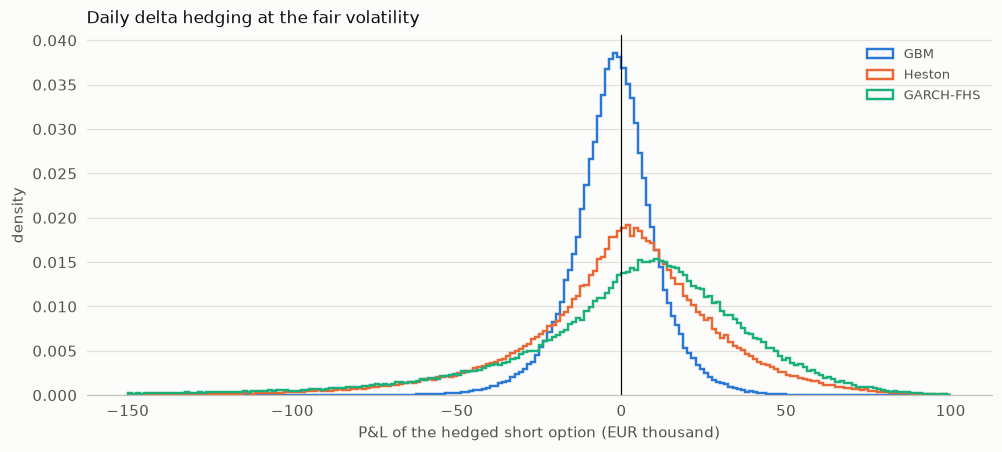

In [4]:
kappa = np.log(2) / (fit.half_life / 252)
theta = uncond * 252 / 1e4
annual_var = s2 * 252 / 1e4                       # historical conditional variances, annualised
vol_of_var = float(np.sqrt(2 * kappa * annual_var.var() / theta))
heston_params = (var_next * 252 / 1e4, kappa, theta, vol_of_var, 0.0)
print(f"Heston: v0 = {heston_params[0]:.5f}, kappa = {kappa:.3f}, theta = {theta:.5f}, sigma_v = {vol_of_var:.4f}, rho = 0")
drift_pct = 100 * (r_usd - r_eur) / 252   # daily drift in percent, consistent with the other two models
garch_params = (drift_pct, p["omega"], p["alpha"], p["gamma"], p["beta"], var_next)
common = dict(S0=spot, K=strike, T=T, r_dom=r_usd, r_for=r_eur, sigma_price=fair_vol, sigma_hedge=fair_vol,
              n_steps=TENOR_DAYS, rebalance_every=1, cost_rate=COST_RATE, mu=r_usd - r_eur, n_paths=N_PATHS, seed=SEED)
scale = NOTIONAL_EUR / spot     # USD per EUR of notional -> EUR for the full notional
t0 = time.perf_counter()
runs = {
    "GBM": hedging.simulate(**common, dynamics="gbm", sigma=fair_vol),
    "Heston": hedging.simulate(**common, dynamics="heston", heston=heston_params),
    "GARCH-FHS": hedging.simulate(**common, dynamics="garch_fhs", garch=garch_params, residuals=z),
}
print(f"3 x {N_PATHS:,} paths x {TENOR_DAYS} daily rebalances in {time.perf_counter() - t0:.1f} s (C++)")
models = hedging.comparison_table(runs, scale)
money = ["premium", "mean", "std. dev.", "MC s.e.", "VaR 95%", "VaR 99%", "ES 97.5%", "mean costs"]
display(models[money].round(0).join(models[["P(loss)"]].round(3)))

fig, ax = plt.subplots(figsize=(9, 4))
for label, out in runs.items():
    ax.hist(out["pnl"] * scale / 1e3, bins=200, range=(-150, 100), histtype="step", lw=1.6, density=True, label=label)
ax.axvline(0, color="k", lw=0.8)
ax.set(xlabel="P&L of the hedged short option (EUR thousand)", ylabel="density", title="Daily delta hedging at the fair volatility")
ax.legend()
fig.savefig(OUTPUT_DIR / "pnl_by_model.png", dpi=150)

## 4. Hedging frequency versus transaction costs

Rebalancing more often reduces the hedging error but increases costs. The table uses the GARCH-FHS dynamics and the same random paths for
every frequency (common random numbers), so differences are due to the hedging policy only.

,mean,std. dev.,ES 97.5%,mean costs,P(loss)
daily,"1,016.0000","41,615.0000","155,580.0000","2,188.0000",0.4010
every 2 days,"1,481.0000","43,643.0000","161,412.0000","1,712.0000",0.4030
weekly,"1,964.0000","48,649.0000","175,682.0000","1,298.0000",0.4090
every 2 weeks,"2,275.0000","55,666.0000","197,316.0000","1,049.0000",0.4200
monthly,"2,307.0000","69,655.0000","244,213.0000",837.0000,0.4320
no hedge,-65.0000,"249,161.0000","885,394.0000",0.0000,0.3400


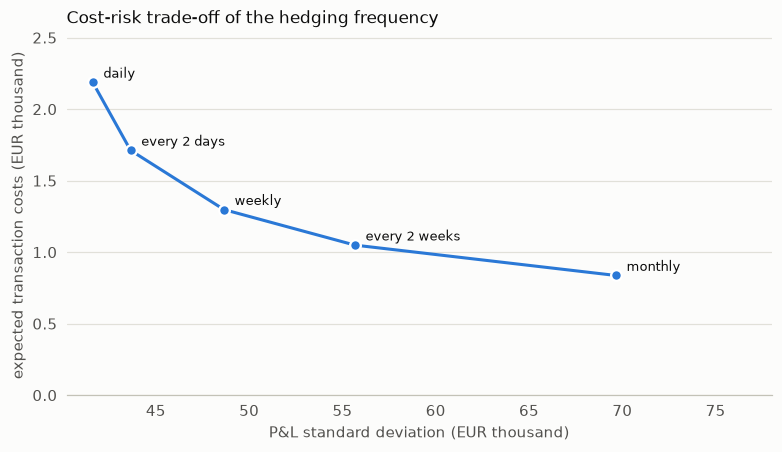

In [5]:
policies = {"daily": 1, "every 2 days": 2, "weekly": 5, "every 2 weeks": 10, "monthly": 21, "no hedge": 0}
frontier = {}
for label, k in policies.items():
    out = hedging.simulate(**{**common, "rebalance_every": k}, dynamics="garch_fhs", garch=garch_params, residuals=z)
    frontier[label] = {**hedging.pnl_summary(out["pnl"], scale=scale), "mean costs": out["costs"].mean() * scale}
frontier = pd.DataFrame(frontier).T
display(frontier[["mean", "std. dev.", "ES 97.5%", "mean costs"]].round(0).join(frontier[["P(loss)"]].round(3)))

fig, ax = plt.subplots(figsize=(7, 4))
hedged = frontier.drop(index="no hedge")
ax.plot(hedged["std. dev."] / 1e3, hedged["mean costs"] / 1e3, "o-", ms=7, mec="white", mew=1.5)
for label, row in hedged.iterrows():
    ax.annotate(label, (row["std. dev."] / 1e3, row["mean costs"] / 1e3), fontsize=8.5, xytext=(7, 3),
                textcoords="offset points")
ax.set_xlim(right=hedged["std. dev."].max() / 1e3 * 1.12)
ax.set_ylim(0, hedged["mean costs"].max() / 1e3 * 1.15)
ax.set(xlabel="P&L standard deviation (EUR thousand)", ylabel="expected transaction costs (EUR thousand)",
       title="Cost-risk trade-off of the hedging frequency")
fig.savefig(OUTPUT_DIR / "hedging_frontier.png", dpi=150)

## 5. Which volatility should the desk quote?

For each quoted volatility we simulate the P&L (daily hedge at the quoted volatility, GARCH-FHS dynamics) and report the probability of a
loss and the expected P&L against the 97.5% Expected Shortfall, the capital-like measure used for market risk under FRTB. A simple
risk-adjusted rule: quote the lowest volatility whose expected P&L pays a 10% annual cost of capital on the ES held for six months.

,premium,mean,ES 97.5%,hurdle,P(loss),meets hurdle
4.89%,"136,570.0000","-27,044.0000","201,717.0000","10,086.0000",0.7557,False
5.14%,"143,551.0000","-20,021.0000","189,700.0000","9,485.0000",0.6645,False
5.39%,"150,532.0000","-13,000.0000","178,015.0000","8,901.0000",0.5719,False
5.64%,"157,514.0000","-5,981.0000","166,641.0000","8,332.0000",0.4829,False
5.89%,"164,494.0000","1,037.0000","155,547.0000","7,777.0000",0.4008,False
6.14%,"171,475.0000","8,053.0000","144,736.0000","7,237.0000",0.3286,True
6.39%,"178,456.0000","15,067.0000","134,201.0000","6,710.0000",0.2670,True
6.64%,"185,437.0000","22,080.0000","123,936.0000","6,197.0000",0.2147,True
6.89%,"192,417.0000","29,091.0000","113,927.0000","5,696.0000",0.1724,True
7.14%,"199,397.0000","36,101.0000","104,170.0000","5,208.0000",0.1370,True


Fair volatility 5.89%; recommended quote: 6.14%


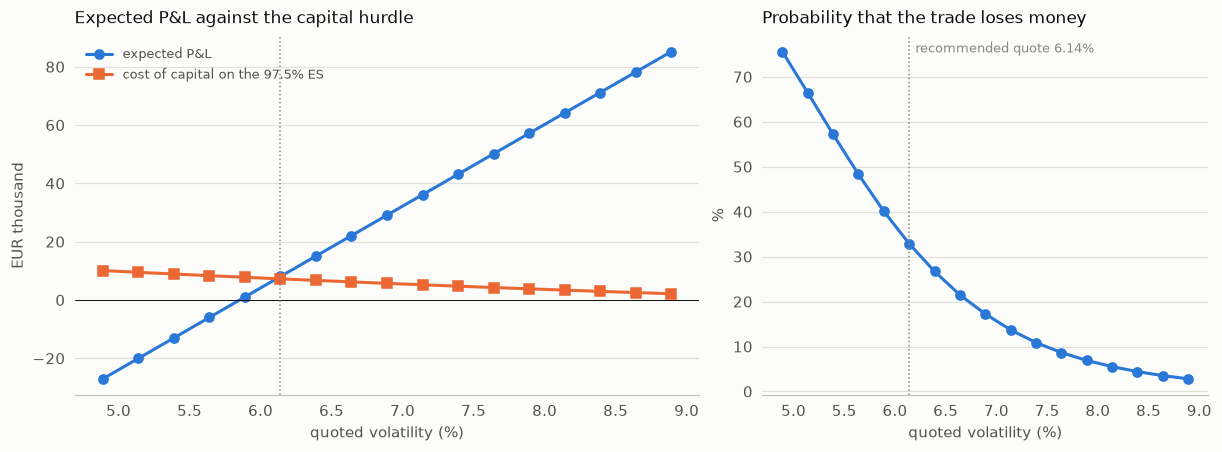

In [6]:
COST_OF_CAPITAL = 0.10
grid = np.round(fair_vol + np.arange(-0.01, 0.0301, 0.0025), 4)
rows = {}
for vol in grid:
    out = hedging.simulate(**{**common, "sigma_price": vol, "sigma_hedge": vol}, dynamics="garch_fhs",
                           garch=garch_params, residuals=z)
    s = hedging.pnl_summary(out["pnl"], out["premium"], scale)
    s["hurdle"] = COST_OF_CAPITAL * T * s["ES 97.5%"]
    rows[f"{100 * vol:.2f}%"] = s
quotes = pd.DataFrame(rows).T
quotes["meets hurdle"] = quotes["mean"] >= quotes["hurdle"]
display(quotes[["premium", "mean", "ES 97.5%", "hurdle"]].round(0).join(quotes[["P(loss)", "meets hurdle"]]))
eligible = quotes[quotes["meets hurdle"]]
recommended = eligible.index[0] if len(eligible) else None
print(f"Fair volatility {100 * fair_vol:.2f}%; recommended quote: {recommended}")

# Two panels with one scale each (a second y-axis would suggest a relation that the scales do not carry).
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.4, 1]})
x = [float(v.rstrip("%")) for v in quotes.index]
axes[0].plot(x, quotes["mean"] / 1e3, "o-", color=SERIES[0], label="expected P&L")
axes[0].plot(x, quotes["hurdle"] / 1e3, "s-", color=SERIES[1], label="cost of capital on the 97.5% ES")
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set(xlabel="quoted volatility (%)", ylabel="EUR thousand", title="Expected P&L against the capital hurdle")
axes[0].legend(loc="upper left")
axes[1].plot(x, 100 * quotes["P(loss)"], "o-", color=SERIES[0])
axes[1].set(xlabel="quoted volatility (%)", ylabel="%", title="Probability that the trade loses money")
if recommended:
    for ax in axes:
        ax.axvline(float(recommended.rstrip("%")), color=MUTED, lw=1, ls=":")
    axes[1].annotate(f"recommended quote {recommended}", (float(recommended.rstrip("%")), axes[1].get_ylim()[1]),
                     xytext=(4, -4), textcoords="offset points", va="top", fontsize=8.5, color=MUTED)
fig.savefig(OUTPUT_DIR / "pricing.png", dpi=150)

## 6. Stress test: selling into a volatility spike

The same trade priced at the current fair volatility, but with the market entering a high-volatility regime right after inception:
the initial GARCH variance is set to the 99th percentile of its historical distribution (for EUR/USD, levels seen in late 2008 and
early 2020).

In [7]:
stressed_var = float(np.quantile(s2, 0.99))
stress = hedging.simulate(**{**common, "sigma_price": fair_vol, "sigma_hedge": fair_vol}, dynamics="garch_fhs",
                          garch=(drift_pct, p["omega"], p["alpha"], p["gamma"], p["beta"], stressed_var), residuals=z)
base = runs["GARCH-FHS"]
table = hedging.comparison_table({"base": base, "stressed start": stress}, scale)
display(table[["mean", "std. dev.", "VaR 99%", "ES 97.5%"]].round(0).join(table[["P(loss)"]].round(3)))
print(f"Initial volatility: base {np.sqrt(var_next * 252):.1f}%, stressed {np.sqrt(stressed_var * 252):.1f}%")

,mean,std. dev.,VaR 99%,ES 97.5%,P(loss)
base,"1,016.0000","41,615.0000","148,458.0000","155,580.0000",0.4010
stressed start,"-306,190.0000","221,889.0000","1,076,336.0000","1,104,358.0000",1.0000


Initial volatility: base 5.2%, stressed 17.7%


## 7. Management summary

The cell below writes the summary for the head of the desk from the computed results.

In [8]:
g = models.loc["GARCH-FHS"]
ratio = models.loc["GARCH-FHS", "ES 97.5%"] / models.loc["GBM", "ES 97.5%"]
daily, weekly = frontier.loc["daily"], frontier.loc["weekly"]
rec = quotes.loc[recommended] if recommended else None
lines = [
    f"Trade: sell a 6-month EUR call/USD put, EUR {NOTIONAL_EUR / 1e6:.0f} million, strike {strike:.4f} (ATM forward), spot {spot:.4f}.",
    f"1. Fair volatility from the GJR-GARCH forecast on ECB data: {100 * fair_vol:.2f}% "
    f"(premium EUR {gk['price'] * scale:,.0f}).",
    f"2. Hedged daily at the fair volatility, the desk's P&L has a mean of EUR {g['mean']:,.0f} and a standard deviation of "
    f"EUR {g['std. dev.']:,.0f}; the 97.5% ES is EUR {g['ES 97.5%']:,.0f}.",
    f"3. Model risk: with realistic fat-tailed shocks (GARCH-FHS) the ES is {ratio:.2f} times the constant-volatility (GBM) figure.",
    f"4. Hedging weekly instead of daily raises the P&L s.d. from EUR {daily['std. dev.']:,.0f} to EUR {weekly['std. dev.']:,.0f} "
    f"while saving EUR {daily['mean costs'] - weekly['mean costs']:,.0f} of expected costs.",
    (f"5. Recommended quote: {recommended} volatility (premium EUR {rec['premium']:,.0f}), with expected P&L EUR {rec['mean']:,.0f}, "
     f"probability of loss {rec['P(loss)']:.0%} and ES EUR {rec['ES 97.5%']:,.0f}." if rec is not None
     else "5. No quote in the grid meets the cost-of-capital hurdle: widen the grid."),
    f"6. Stress: if volatility spikes right after inception, the ES rises to EUR {table.loc['stressed start', 'ES 97.5%']:,.0f}; "
    "desk limits should be sized on this figure, not on the base case.",
]
print("\n".join(lines))
_ = (OUTPUT_DIR / "management_summary.txt").write_text("\n".join(lines) + "\n", encoding="utf-8")

Trade: sell a 6-month EUR call/USD put, EUR 10 million, strike 1.1839 (ATM forward), spot 1.1750.
1. Fair volatility from the GJR-GARCH forecast on ECB data: 5.89% (premium EUR 164,474).
2. Hedged daily at the fair volatility, the desk's P&L has a mean of EUR 1,016 and a standard deviation of EUR 41,615; the 97.5% ES is EUR 155,580.
3. Model risk: with realistic fat-tailed shocks (GARCH-FHS) the ES is 4.05 times the constant-volatility (GBM) figure.
4. Hedging weekly instead of daily raises the P&L s.d. from EUR 41,615 to EUR 48,649 while saving EUR 890 of expected costs.
5. Recommended quote: 6.14% volatility (premium EUR 171,475), with expected P&L EUR 8,053, probability of loss 33% and ES EUR 144,736.
6. Stress: if volatility spikes right after inception, the ES rises to EUR 1,104,358; desk limits should be sized on this figure, not on the base case.


### Limitations and next steps

- Only spot delta hedging: a real desk also hedges vega with other options and prices the volatility smile (for example with SABR or
  vanna-volga); the Heston run gives a first view of that risk.
- The client's credit risk (CVA), funding (FVA) and capital (KVA) adjustments are not included.
- Rates are constant over the option's life; for six months this is a minor effect compared with volatility risk.

### References

- Barone-Adesi, G., Giannopoulos, K. and Vosper, L. (1999). VaR without correlations for portfolios of derivative securities. *Journal of Futures Markets*, 19(5), 583-602.
- Basel Committee on Banking Supervision (2019). Minimum capital requirements for market risk, MAR33.
- Garman, M. B. and Kohlhagen, S. W. (1983). Foreign currency option values. *Journal of International Money and Finance*, 2(3), 231-237.
- Kamal, M. and Derman, E. (1999). When you cannot hedge continuously: the corrections of Black-Scholes. *Risk*, 12(1), 82-85.
- European Central Bank: euro foreign exchange reference rates and euro area yield curves. FRED, series DTB3 (Board of Governors of the Federal Reserve System).